# Assess Uncertainty Scenarios with Claude API

This notebook processes scenario assessment templates through Claude API to evaluate uncertainty scenarios. It takes the templates generated in the scenario_assessments directory and obtains thorough evaluations for each scenario.

## Features
- Uses Claude API to assess uncertainty scenarios based on assessment templates
- Supports multiprocessing for parallel assessment processing
- Organizes results by domain, function, and uncertainty type
- Processes all 918 assessment templates

## Install Dependencies

In [1]:
# # Install required packages
# !pip install -q pandas tqdm notebook python-dotenv anthropic

## Import Libraries

In [2]:
import os
import json
import time
import glob
import re
import multiprocessing
import random
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.notebook import tqdm
import pandas as pd
from dotenv import load_dotenv

# Check for Anthropic library availability
try:
    from anthropic import AnthropicBedrock
    print("AnthropicBedrock library found.")
    anthropic_bedrock_available = True
except ImportError:
    print("AnthropicBedrock library not found. Will try regular Anthropic client.")
    anthropic_bedrock_available = False
    try:
        from anthropic import Anthropic
        print("Anthropic library found.")
        anthropic_available = True
    except ImportError:
        print("Neither Anthropic nor AnthropicBedrock libraries are available.")
        anthropic_available = False

# Load environment variables
load_dotenv()

AnthropicBedrock library found.


True

## Configure API Settings

In [3]:
# Setup client based on available library
aws_access_key=os.environ.get("BEDROCK_ACCESS_KEY") or os.environ.get("AWS_ACCESS_KEY_ID")
aws_secret_key=os.environ.get("BEDROCK_SECRET_ACCESS_KEY") or os.environ.get("AWS_SECRET_ACCESS_KEY")
if anthropic_bedrock_available:
    client = AnthropicBedrock(
        aws_access_key=aws_access_key,
        aws_secret_key=aws_secret_key,
        aws_region= "us-east-1" # os.environ.get("AWS_REGION", "us-east-1")
    )
    model = "us.anthropic.claude-3-7-sonnet-20250219-v1:0" # "anthropic.claude-3-sonnet-20240229-v1:0"
elif anthropic_available:
    client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY"))
    model = "claude-3-sonnet-20240229"
else:
    raise ImportError("No Anthropic client available. Please install the required library.")

# Configure parallel processing
max_workers = min(multiprocessing.cpu_count() * 2, 50)  # Use at most 16 parallel workers
print(f"Using {max_workers} parallel workers for processing.")
model

Using 50 parallel workers for processing.


'us.anthropic.claude-3-7-sonnet-20250219-v1:0'

## Define Assessment Processing Functions

In [4]:
def read_assessment_template(template_path):
    """Read assessment template from file"""
    with open(template_path, 'r', encoding='utf-8') as f:
        return f.read()

def extract_metadata_from_path(template_path):
    """Extract metadata from template file path"""
    # Parse path like scenario_assessments/SmartHomeEnv_volume_adjust_unclear_functionality_boundaries_run_0_assessment.md
    filename = Path(template_path).name
    parts = filename.replace('_assessment.md', '').split('__')
    
    if len(parts) >= 4:
        domain = parts[0]
        function = parts[1]
        
        # Handle uncertainty type which could have multiple parts (e.g., unclear_functionality_boundaries)
        # run_index = parts.index('run')  # Find where 'run' appears
        uncertainty_type = parts[2] # '_'.join(parts[2:run_index])
        run = parts[3]  # Get the run number, which is right after 'run'
        
        return {
            "domain": domain,
            "function": function,
            "uncertainty_type": uncertainty_type,
            "run": run
        }
    else:
        # Default structure if parsing fails
        return {
            "domain": "unknown",
            "function": "unknown",
            "uncertainty_type": "unknown",
            "run": "0"
        }

def generate_assessment_prompt(template_content):
    """Generate a prompt for Claude to assess the scenario"""
    prompt = f"""You are an expert evaluator of API uncertainty scenarios. Please carefully assess the following scenario template according to the assessment criteria provided within it.  

Your task is to:
1. Read the scenario and understand how the API function is supposed to work
2. Understand the specific uncertainty type that should be demonstrated
3. Evaluate how well the scenario demonstrates this uncertainty
4. Provide scores and rationales for each assessment dimension
5. Calculate the overall score and provide a summary assessment
6. Suggest specific improvements if the score is below 4.0

PAY SPECIAL ATTENTION to completing the "OUTPUT FORMAT" section with your detailed assessment. This section MUST be filled out completely according to the instructions, including:
- Dimension Scores table with accurate calculations
- Score Classification with correct interpretation
- Primary Strengths and Weaknesses
- Improvement Recommendations
- Final Determination

Calculate the weighted scores correctly by multiplying each score by 0.3333, and calculate the total score as their sum. Choose the correct Classification based on the total score using the Interpretation Scale provided.

TEMPLATE TO COMPLETE:

{template_content}
"""
    return prompt

def process_assessment_with_claude(template_path, retry_count=300):
    """Process assessment template with Claude API and handle retries"""
    template_content = read_assessment_template(template_path)
    metadata = extract_metadata_from_path(template_path)
    prompt = generate_assessment_prompt(template_content)
    
    # Try multiple times in case of API failures
    for attempt in range(retry_count):
        try:
            if anthropic_bedrock_available:
                response = client.messages.create(
                    model=model,
                    max_tokens=15000,
                    messages=[
                        {"role": "user", "content": prompt}
                    ]
                )
                completed_assessment = response.content[0].text
            else:  # Using standard Anthropic client
                response = client.messages.create(
                    model=model,
                    max_tokens=15000,
                    messages=[
                        {"role": "user", "content": prompt}
                    ]
                )
                completed_assessment = response.content[0].text
            
            # Success - return the assessment and metadata
            return {
                **metadata,
                "assessment": completed_assessment,
                "template_path": template_path,
                "success": True
            }
        except Exception as e:
            if attempt == retry_count - 1:  # Last attempt failed
                print(f"Failed to process {template_path} after {retry_count} attempts: {e}")
                return {
                    **metadata,
                    "assessment": f"Error: {str(e)}",
                    "template_path": template_path,
                    "success": False
                }
            else:
                # Wait with exponential backoff before retry
                wait_time = 2 ** attempt
                print(f"Attempt {attempt + 1} failed for {template_path}, retrying in {wait_time}s: {e}")
                time.sleep(wait_time)

def save_assessment_result(result, output_dir="scenario_evaluations"):
    """Save assessment result to a well-organized directory structure"""
    # Create output directory structure
    domain_dir = Path(output_dir) / result["domain"]
    function_dir = domain_dir / result["function"]
    uncertainty_dir = function_dir / result["uncertainty_type"]
    os.makedirs(uncertainty_dir, exist_ok=True)
    
    # Define output file path
    output_path = uncertainty_dir / f"assessment_run_{result['run']}.md"
    
    # Save the assessment
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(result["assessment"])
        
    # Also save metadata and assessment in JSON format for easier analysis
    json_path = uncertainty_dir / f"assessment_run_{result['run']}.json"
    json_data = {
        "domain": result["domain"],
        "function": result["function"],
        "uncertainty_type": result["uncertainty_type"],
        "run": result["run"],
        "template_path": result["template_path"],
        "success": result["success"],
        "assessment": result["assessment"]
    }
    
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2)
    
    return output_path

## Process Assessment Templates

In [5]:
# Get all assessment template files
assessment_templates = glob.glob("scenario_assessments/*_assessment.md")
print(f"Found {len(assessment_templates)} assessment templates to process.")

Found 918 assessment templates to process.


In [6]:
# Create output directory
output_dir = "scenario_evaluations"
os.makedirs(output_dir, exist_ok=True)

In [1]:
# assessment_templates = [f for f in assessment_templates if f.find("ad_hoc")>-1]
# assessment_templates

In [7]:
# Process templates in parallel
def process_templates_parallel():
    results = []
    
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks
        futures = [executor.submit(process_assessment_with_claude, template) for template in assessment_templates]
        
        # Process results as they complete
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing assessments"):
            try:
                result = future.result()
                if result["success"]:
                    output_path = save_assessment_result(result, output_dir)
                    result["output_path"] = str(output_path)
                results.append(result)
            except Exception as e:
                print(f"Error processing template: {e}")
    
    return results

In [8]:
# Run the parallel processing
assessment_results = process_templates_parallel()

Processing assessments:   0%|          | 0/918 [00:00<?, ?it/s]

Attempt 1 failed for scenario_assessments/TimeNotificationEnv__get_reminders__ambiguous_documentation__run_3_assessment.md, retrying in 1s: Error code: 429 - {'message': 'Too many tokens, please wait before trying again.'}
Attempt 1 failed for scenario_assessments/MediaControlEnv__get_media_details__unclear_functionality_boundaries__run_0_assessment.md, retrying in 1s: Error code: 429 - {'message': 'Too many tokens, please wait before trying again.'}
Attempt 1 failed for scenario_assessments/CommunicationController__make_call__ad_hoc_rules__run_3_assessment.md, retrying in 1s: Error code: 429 - {'message': 'Too many tokens, please wait before trying again.'}
Attempt 1 failed for scenario_assessments/SmartHomeEnv__brightness_adjust__ad_hoc_rules__run_7_assessment.md, retrying in 1s: Error code: 429 - {'message': 'Too many tokens, please wait before trying again.'}
Attempt 1 failed for scenario_assessments/CommunicationController__make_call__ad_hoc_rules__run_1_assessment.md, retrying in

## Analyze Results

In [9]:
# Convert results to DataFrame for analysis
results_df = pd.DataFrame(assessment_results)
results_df["success"] = results_df["success"].astype(bool)

# Print summary
print("Assessment Processing Summary:")
print(f"Total templates processed: {len(results_df)}")
print(f"Successful assessments: {results_df['success'].sum()}")
print(f"Failed assessments: {len(results_df) - results_df['success'].sum()}")

Assessment Processing Summary:
Total templates processed: 918
Successful assessments: 918
Failed assessments: 0


In [10]:
# Save results summary
results_df.to_csv(Path(output_dir) / "assessment_results_summary.csv", index=False)

## Extract Scores (Optional)

In [11]:
# Extract scores from successful assessments
def extract_scores_from_assessment(assessment_text):
    try:
        # Try to extract scores from the table format first
        # Look for a line like: | Real-world Resonance | 4 | 33.33% | 1.33 |
        resonance_match = re.search(r'\| Real-world Resonance \| (\d+(?:\.\d+)?) \|', assessment_text)
        conformance_match = re.search(r'\| Uncertainty-Type Conformance \| (\d+(?:\.\d+)?) \|', assessment_text)
        efficiency_match = re.search(r'\| Implementation Efficiency \| (\d+(?:\.\d+)?) \|', assessment_text)
        total_match = re.search(r'\*\*TOTAL\*\* \|[^|]*\| \*\*(\d+(?:\.\d+)?)\*\*', assessment_text)
        
        # Fall back to the old dimension names if needed
        if not resonance_match:
            resonance_match = re.search(r'\| Ecological Validity \| (\d+(?:\.\d+)?) \|', assessment_text)
        if not conformance_match:
            conformance_match = re.search(r'\| Uncertainty-Type Fidelity \| (\d+(?:\.\d+)?) \|', assessment_text) 
        if not efficiency_match:
            efficiency_match = re.search(r'\| Implementation Elegance \| (\d+(?:\.\d+)?) \|', assessment_text)
            
        # If table format didn't work, try the older format with **Score:** notation
        if not resonance_match:
            # First try to find all scores in one go
            all_scores = re.findall(r'\*\*Score:\*\*\s*(\d+(?:\.\d+)?)', assessment_text)
            if len(all_scores) >= 3:
                resonance_score = float(all_scores[0])
                conformance_score = float(all_scores[1])
                efficiency_score = float(all_scores[2])
            else:  
                # If that didn't work, try the individual patterns
                resonance_match = re.search(r'\*\*Score:\*\*\s*(\d+(?:\.\d+)?)', assessment_text)
                if resonance_match:
                    # Try to find second score by searching after the first
                    conformance_match = re.search(r'\*\*Score:\*\*\s*(\d+(?:\.\d+)?)', 
                                              assessment_text[resonance_match.end():])
                    # Try to find third score by searching after the second
                    if conformance_match:
                        search_pos = resonance_match.end() + conformance_match.end()
                        efficiency_match = re.search(r'\*\*Score:\*\*\s*(\d+(?:\.\d+)?)', 
                                               assessment_text[search_pos:])
            
            # Try to find total score
            total_match = re.search(r'\*\*Total Score:\*\*\s*(\d+(?:\.\d+)?)', assessment_text)
        
        # Extract the scores
        if 'resonance_score' in locals():
            # We already extracted from all_scores
            pass
        else:
            resonance_score = float(resonance_match.group(1)) if resonance_match else None
            conformance_score = float(conformance_match.group(1)) if conformance_match else None
            efficiency_score = float(efficiency_match.group(1)) if efficiency_match else None
            
        total_score = float(total_match.group(1)) if total_match else None
        
        # If total score is missing, calculate it
        if total_score is None and all([resonance_score, conformance_score, efficiency_score]):
            total_score = round((resonance_score + conformance_score + efficiency_score) / 3, 2)
        
        return {
            "real_world_resonance_score": resonance_score,
            "uncertainty_type_conformance_score": conformance_score,
            "implementation_efficiency_score": efficiency_score,
            "total_score": total_score
        }
    except Exception as e:
        print(f"Error extracting scores: {e}")
        return {
            "real_world_resonance_score": None,
            "uncertainty_type_conformance_score": None,
            "implementation_efficiency_score": None,
            "total_score": None
        }

In [12]:
# Extract scores for successful assessments
scores_data = []
for _, row in tqdm(results_df[results_df["success"]].iterrows(), desc="Extracting scores"):
    scores = extract_scores_from_assessment(row["assessment"])
    scores_data.append({
        "domain": row["domain"],
        "function": row["function"],
        "uncertainty_type": row["uncertainty_type"],
        "run": row["run"],
        **scores
    })

scores_df = pd.DataFrame(scores_data)
scores_df.to_csv(Path(output_dir) / "assessment_scores.csv", index=False)

Extracting scores: 0it [00:00, ?it/s]

## Score Analysis

In [13]:
scores_df

,domain,function,uncertainty_type,run,real_world_resonance_score,uncertainty_type_conformance_score,implementation_efficiency_score,total_score
0,SmartHomeEnv,open_set_position,unclear_functionality_boundaries,run_7,9.0,10.0,9.0,9.33
1,InformationControlEnv,weather_alerts,ambiguous_documentation,run_1,9.0,10.0,9.0,9.33
2,CulinaryControlEnv,place_delivery_order,ambiguous_documentation,run_0,9.0,10.0,9.0,9.33
3,InformationControlEnv,stock_watchlist,ad_hoc_rules,run_2,9.0,8.0,8.0,8.33
4,CommunicationController,make_call,unclear_functionality_boundaries,run_2,9.0,10.0,9.0,9.33
...,...,...,...,...,...,...,...,...
913,SmartHomeEnv,brightness_adjust,ad_hoc_rules,run_4,9.0,9.0,8.0,8.67
914,CommunicationController,make_call,ad_hoc_rules,run_1,9.0,9.0,8.0,8.67
915,TransactionEnv,checkout,ambiguous_documentation,run_0,9.0,10.0,8.0,9.00
916,CommunicationController,make_call,ad_hoc_rules,run_3,9.0,8.0,9.0,8.67


In [14]:
# Analyze scores by domain
domain_scores = scores_df.groupby('domain')[["real_world_resonance_score", "uncertainty_type_conformance_score", 
                                             "implementation_efficiency_score", "total_score"]].mean()
domain_scores

,real_world_resonance_score,uncertainty_type_conformance_score,implementation_efficiency_score,total_score
domain,,,,
CommunicationController,9.000000,9.767677,8.838384,9.200000
CulinaryControlEnv,9.000000,9.638889,8.675926,9.103796
InformationControlEnv,9.000000,9.255556,8.577778,8.943667
MediaControlEnv,8.895833,9.416667,8.666667,8.991806
SmartHomeEnv,8.957516,9.666667,8.725490,9.114706
TimeNotificationEnv,8.985185,9.703704,8.785185,9.155852
TransactionEnv,8.972222,8.694444,8.361111,8.675556


In [15]:
# Analyze scores by uncertainty type
uncertainty_scores = scores_df.groupby('uncertainty_type')[["real_world_resonance_score", "uncertainty_type_conformance_score", 
                                                          "implementation_efficiency_score", "total_score"]].mean()
uncertainty_scores

,real_world_resonance_score,uncertainty_type_conformance_score,implementation_efficiency_score,total_score
uncertainty_type,,,,
ad_hoc_rules,8.895425,9.062092,8.522876,8.826373
ambiguous_documentation,9.006536,9.699346,8.624183,9.108627
unclear_functionality_boundaries,8.996732,9.924837,8.960784,9.291209


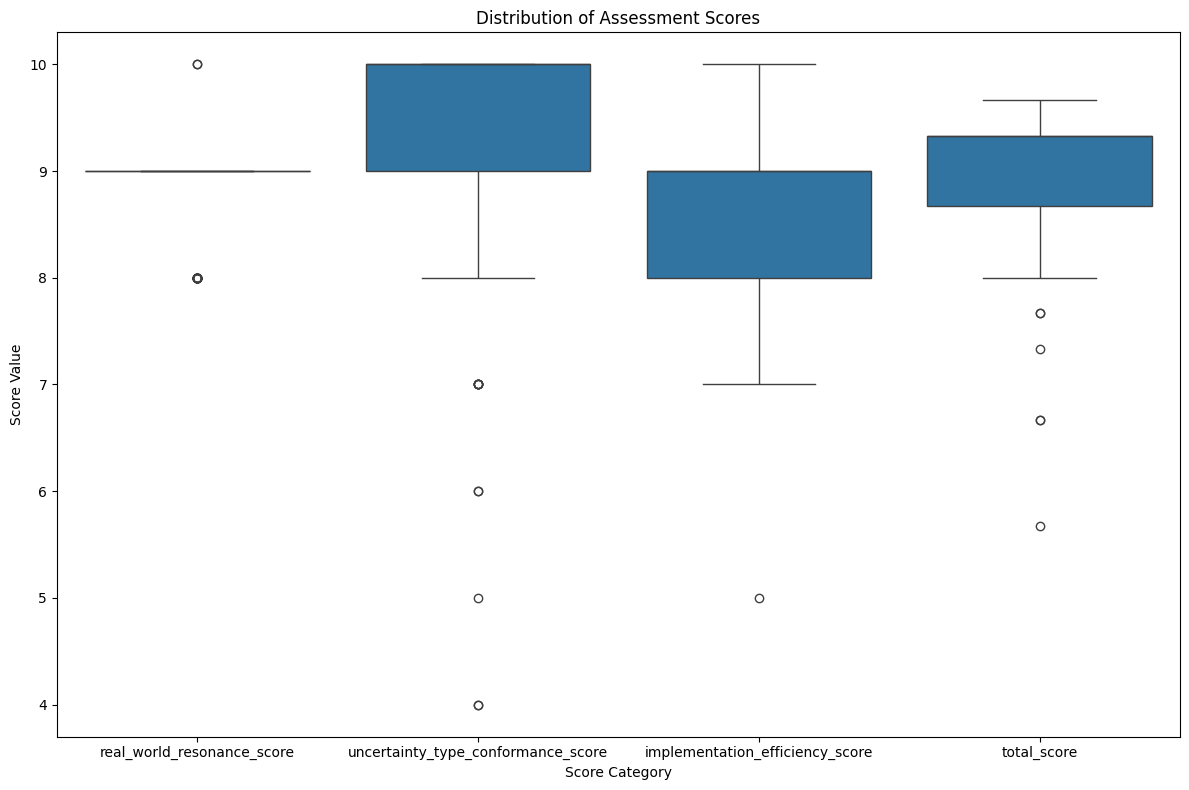

In [16]:
# Plot score distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(data=scores_df.melt(id_vars=['domain', 'function', 'uncertainty_type', 'run'], 
                               value_vars=['real_world_resonance_score', 'uncertainty_type_conformance_score', 
                                          'implementation_efficiency_score', 'total_score']),
           x='variable', y='value')
plt.title('Distribution of Assessment Scores')
plt.xlabel('Score Category')
plt.ylabel('Score Value')
plt.tight_layout()
plt.savefig(Path(output_dir) / 'score_distributions.png')
plt.show()